
# Kit d'illustrations — Statistique descriptive (pandas, matplotlib, seaborn)

**Objectif.** Ce notebook sert de *boîte à outils* pour illustrer les notions clés de statistique descriptive.  
Pour chaque notion, on fournit :
- une explication niveau fin secondaire,
- **deux versions de code** (Matplotlib **et** Seaborn),
- une **fonction réutilisable** pour automatiser l'illustration.

> Astuce pédagogique : montrez d'abord la version **Matplotlib** (contrôle fin, bas niveau), puis la version **Seaborn** (API haut niveau, plus concise).



## 0) Préambule & données de démonstration

On importe les bibliothèques, on fixe un style d'affichage, puis on crée un petit **jeu de données synthétique** pour illustrer les notions.  
- `taille_cm`, `poids_kg` suivent des distributions à peu près normales.  
- `revenu_k€` suit une distribution **asymétrique** (log-normale), utile pour discuter de la moyenne vs médiane et des outliers.  
- `groupe` est une **catégorie** (A/B/C) pour les comparaisons inter-groupes.


In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Style d'affichage

plt.rcParams["figure.figsize"] = (6, 4)
sns.set_theme()

# Données jouet
rng = np.random.default_rng(42)
n = 300
df = pd.DataFrame({
    "taille_cm": rng.normal(170, 8, n),                 # ~ normale
    "poids_kg":  rng.normal(70, 12, n),                 # ~ normale
    "revenu_k€": rng.lognormal(mean=3.0, sigma=0.5, size=n),  # asymétrique (skew)
    "groupe": rng.choice(["A", "B", "C"], size=n, p=[0.4, 0.4, 0.2])
})
# Lien léger taille-poids (corrélation positive modérée)
df["poids_kg"] = df["poids_kg"] + 0.35*(df["taille_cm"] - 170)

df.head()


,taille_cm,poids_kg,revenu_k€,groupe
0,172.437737,91.581410,25.989827,B
1,161.680127,48.681708,15.047781,B
2,176.003610,82.467200,37.986226,B
3,177.524518,68.691279,14.675893,A
4,154.391718,63.801209,14.609797,C



---
## 1) Tendances centrales : moyenne, médiane, mode

**Idée.** On cherche un **centre** de la distribution.
- **Moyenne** : somme ÷ nombre de valeurs. Très utilisée mais **sensible aux valeurs extrêmes**.
- **Médiane** : valeur qui coupe l'échantillon en deux (50 % en dessous, 50 % au-dessus). **Robuste** aux valeurs extrêmes.
- **Mode** : valeur (ou catégorie) la plus fréquente. En continu, on observe souvent le **pic** de la densité.

**Quand utiliser quoi ?**
- Données **symétriques** sans outliers : la moyenne est pertinente.
- Données **asymétriques** / avec outliers : la médiane donne un centre plus fiable.


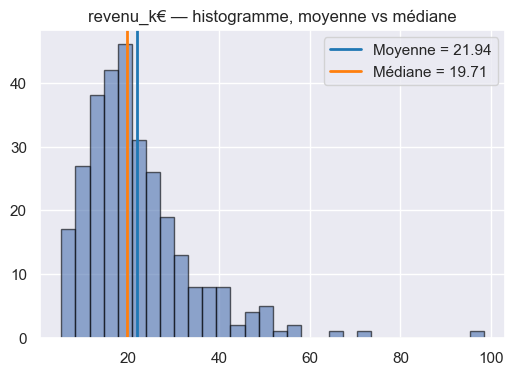

In [2]:

# Matplotlib — Histogramme avec moyenne & médiane annotées
col = "revenu_k€"
x = df[col]
mu, med = x.mean(), x.median()

fig, ax = plt.subplots()
ax.hist(x, bins=30, alpha=0.6, edgecolor="black")
ax.axvline(mu,  color="tab:blue",  linewidth=2, label=f"Moyenne = {mu:.2f}")
ax.axvline(med, color="tab:orange",linewidth=2, label=f"Médiane = {med:.2f}")
ax.set_title(f"{col} — histogramme, moyenne vs médiane")
ax.legend()
plt.show()


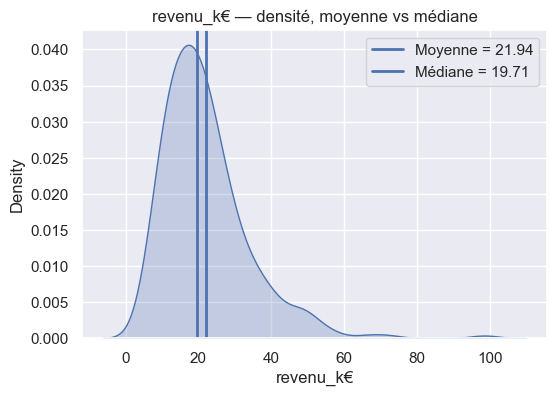

In [3]:

# Seaborn — Densité (KDE) avec lignes de moyenne & médiane
col = "revenu_k€"
x = df[col]
mu, med = x.mean(), x.median()

ax = sns.kdeplot(x, fill=True)
ax.axvline(mu,  linewidth=2, label=f"Moyenne = {mu:.2f}")
ax.axvline(med, linewidth=2, label=f"Médiane = {med:.2f}")
ax.set_title(f"{col} — densité, moyenne vs médiane")
ax.legend()
plt.show()


In [4]:

# Fonction réutilisable — centre
def summarize_center(s: pd.Series):
    mode = s.mode()
    return {
        "mean": s.mean(),
        "median": s.median(),
        "mode": mode.iloc[0] if not mode.empty else None
    }

summarize_center(df["revenu_k€"])


{'mean': np.float64(21.939256878822203),
 'median': np.float64(19.71477560043119),
 'mode': np.float64(5.278187611783475)}


---
## 2) Dispersion : variance, écart-type, IQR

**Pourquoi ça compte ?** Deux classes ayant la même moyenne peuvent être très **différentes** si l'une est très **éparpillée**.
- **Variance** : moyenne des carrés des écarts à la moyenne (unité au carré).
- **Écart-type (σ)** : racine de la variance (même unité que la variable).
- **IQR** (*InterQuartile Range*) : Q3 − Q1, mesure **robuste** car ignore les 25 % extrêmes de chaque côté.

**Interprétation rapide :**
- Grand σ → données très dispersées autour de la moyenne.
- Grand IQR → cœur de distribution large (robuste aux outliers).


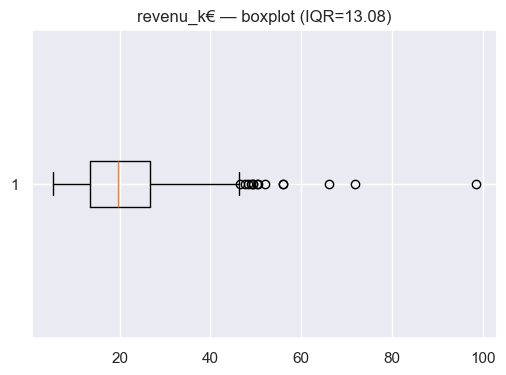

In [5]:

# Matplotlib — Boxplot horizontal et IQR
col = "revenu_k€"
q1, q3 = df[col].quantile([0.25, 0.75])
iqr = q3 - q1

fig, ax = plt.subplots()
ax.boxplot(df[col], vert=False)
ax.set_title(f"{col} — boxplot (IQR={iqr:.2f})")
plt.show()


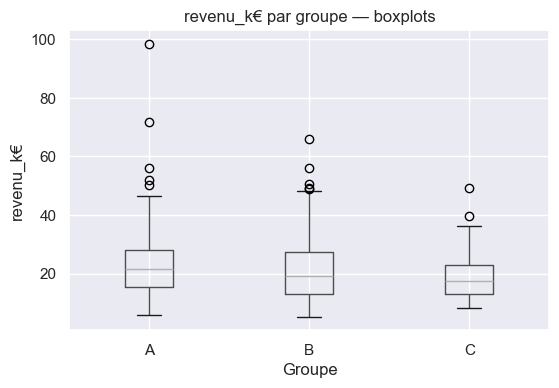

In [7]:
# Matplotlib boxplot par groupe
col = "revenu_k€"
fig, ax = plt.subplots()
df.boxplot(column=col, by="groupe", ax=ax)
ax.set_title(f"{col} par groupe — boxplots")
ax.set_xlabel("Groupe")
ax.set_ylabel(col)
plt.suptitle("")  # Supprimer le titre par défaut généré par pandas
plt.show()

# Seaborn — Violinplot par groupe

# col = "revenu_k€"
# ax = sns.violinplot(x="groupe", y=col, data=df)
# ax.set_title(f"{col} par groupe — violin plots")
# plt.show()


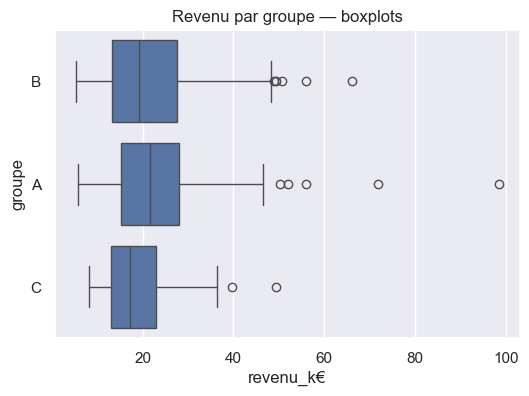

In [6]:

# Seaborn — Boxplot par groupe
sns.boxplot(data=df, x="revenu_k€", y="groupe")
plt.title("Revenu par groupe — boxplots")
plt.show()


In [8]:

# Fonction réutilisable — dispersion
def summarize_dispersion(s: pd.Series):
    q = s.quantile([0.25, 0.5, 0.75])
    return {
        "variance": s.var(ddof=1),
        "std": s.std(ddof=1),
        "Q1": q.loc[0.25],
        "median": q.loc[0.5],
        "Q3": q.loc[0.75],
        "IQR": q.loc[0.75] - q.loc[0.25]
    }

summarize_dispersion(df["revenu_k€"])


{'variance': np.float64(141.29989546893205),
 'std': np.float64(11.886963256817616),
 'Q1': np.float64(13.54182020668593),
 'median': np.float64(19.71477560043119),
 'Q3': np.float64(26.626617372739656),
 'IQR': np.float64(13.084797166053725)}


---
## 3) Forme de la distribution : asymétrie (skewness) & aplatissement (kurtosis)

- **Skewness (asymétrie)** : si la queue droite est longue, la distribution est **asymétrique à droite** (skew > 0).  
- **Kurtosis** : mesure la **concentration** au centre et l'importance des **queues**. Une forte kurtosis signifie des **queues plus lourdes**.

**En pratique :**
- Données fortement asymétriques → penser à une **transformation** (ex : log).
- Mismatch moyenne/médiane → symptôme d'asymétrie.


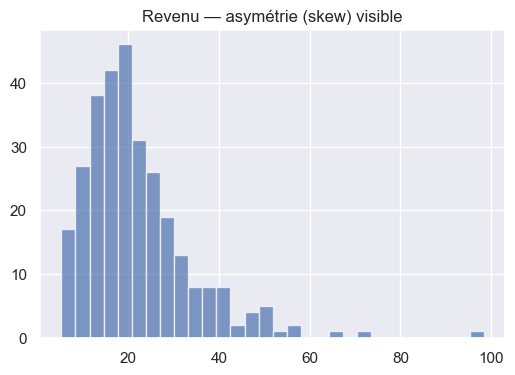

In [9]:

# Matplotlib — Histogramme pour voir l'asymétrie
fig, ax = plt.subplots()
ax.hist(df["revenu_k€"], bins=30, alpha=0.7)
ax.set_title("Revenu — asymétrie (skew) visible")
plt.show()


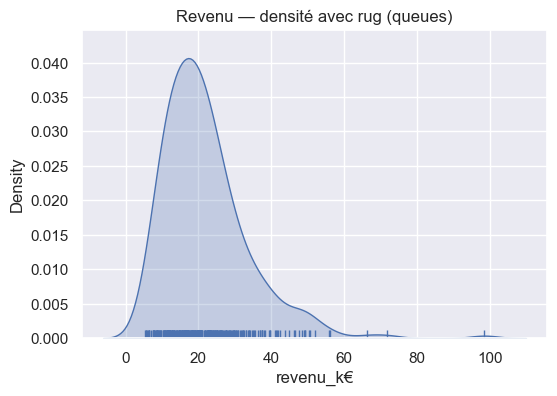

In [10]:

# Seaborn — KDE + Rug pour voir la concentration et les queues
sns.kdeplot(df["revenu_k€"], fill=True)
sns.rugplot(df["revenu_k€"])
plt.title("Revenu — densité avec rug (queues)")
plt.show()


In [11]:

# Fonction — skew & kurtosis
def shape_metrics(s: pd.Series):
    return {"skew": s.skew(), "kurtosis": s.kurt()}

shape_metrics(df["revenu_k€"])


{'skew': np.float64(1.8702991427901374),
 'kurtosis': np.float64(6.640105985180819)}


---
## 4) Position & standardisation : quantiles, z-scores

- **Quantiles/percentiles** : repères de position (ex : médiane = 50e percentile).
- **z-score** : combien d'**écarts-types** une valeur est au-dessus/au-dessous de la moyenne.

**Utilité :**
- Comparer des variables de **scales** différentes.
- Repérer des valeurs **atypiques** (z très grand en valeur absolue).


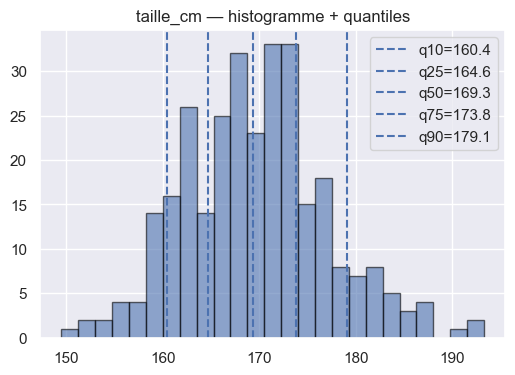

In [12]:

# Matplotlib — Histogramme + lignes de quantiles
col = "taille_cm"; x = df[col]
q = x.quantile([.1,.25,.5,.75,.9])

fig, ax = plt.subplots()
ax.hist(x, bins=25, alpha=0.6, edgecolor="black")
for p, v in q.items():
    ax.axvline(v, linestyle="--", label=f"q{int(p*100)}={v:.1f}")
ax.legend(); ax.set_title(f"{col} — histogramme + quantiles")
plt.show()


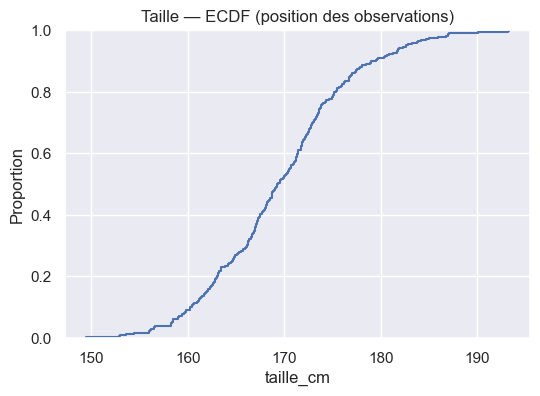

In [13]:

# Seaborn — ECDF (fonction de répartition empirique)
sns.ecdfplot(df["taille_cm"])
plt.title("Taille — ECDF (position des observations)")
plt.show()


In [14]:

# Fonctions — zscore et quantiles
def zscore(s: pd.Series):
    return (s - s.mean())/s.std(ddof=1)

def quantiles(s: pd.Series, qs=(.25,.5,.75)):
    return s.quantile(qs)

z = zscore(df["taille_cm"])
z.describe()


count    3.000000e+02
mean    -8.359979e-16
std      1.000000e+00
min     -2.714883e+00
25%     -6.753787e-01
50%     -4.935275e-02
75%      5.533529e-01
max      3.176428e+00
Name: taille_cm, dtype: float64


---
## 5) Relations bivariées : covariance & corrélation

- **Covariance** : mesure la variation conjointe. Dépend des **unités**, donc peu comparable entre paires.
- **Corrélation de Pearson (r)** : covariance **standardisée** entre −1 et 1.  
  - r > 0 : relation linéaire positive.
  - r < 0 : relation linéaire négative.
  - r ≈ 0 : pas de relation **linéaire** (mais il peut en exister une **non linéaire**).

**Attention :** corrélation ≠ causalité.


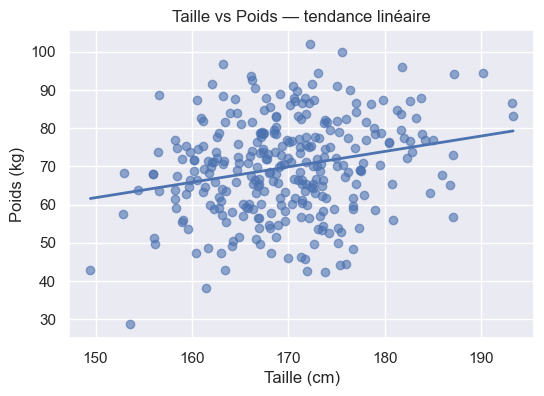

In [15]:

# Matplotlib — Nuage de points + droite d'ajustement
x, y = df["taille_cm"], df["poids_kg"]
coef = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
yy = coef[0]*xx + coef[1]

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.6)
ax.plot(xx, yy, linewidth=2)
ax.set_xlabel("Taille (cm)"); ax.set_ylabel("Poids (kg)")
ax.set_title("Taille vs Poids — tendance linéaire")
plt.show()


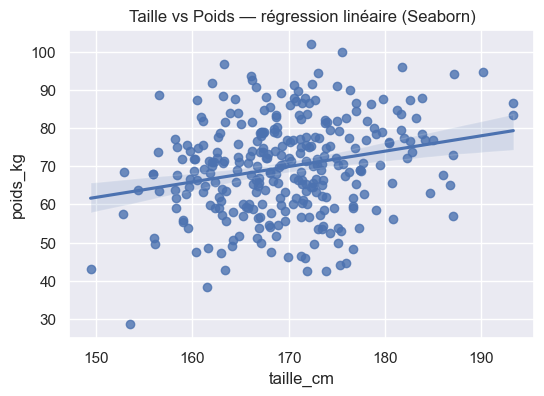

In [16]:

# Seaborn — regplot (régression linéaire)
sns.regplot(data=df, x="taille_cm", y="poids_kg")
plt.title("Taille vs Poids — régression linéaire (Seaborn)")
plt.show()


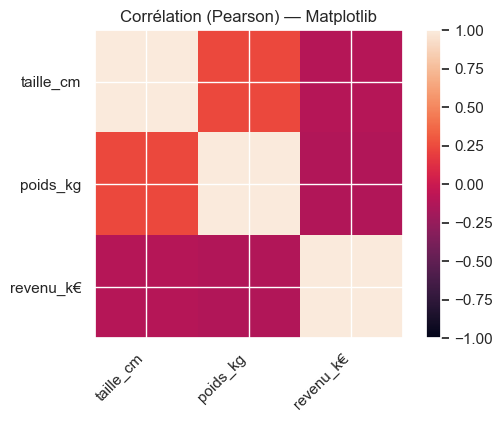

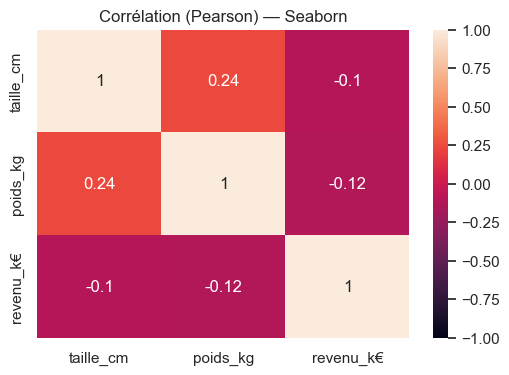

In [17]:

# Matrices de corrélations (Matplotlib & Seaborn)
corr = df[["taille_cm","poids_kg","revenu_k€"]].corr()

# Matplotlib
fig, ax = plt.subplots()
cax = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(corr.shape[1])); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(corr.shape[0])); ax.set_yticklabels(corr.index)
fig.colorbar(cax); ax.set_title("Corrélation (Pearson) — Matplotlib")
plt.show()

# Seaborn
sns.heatmap(corr, annot=True, vmin=-1, vmax=1)
plt.title("Corrélation (Pearson) — Seaborn")
plt.show()


In [18]:

# Fonctions — covariance & corrélation
def cov_corr(df, cols):
    sub = df[cols].dropna()
    return {"cov": sub.cov(), "corr": sub.corr()}

cov_corr(df, ["taille_cm","poids_kg","revenu_k€"])["corr"]


,taille_cm,poids_kg,revenu_k€
taille_cm,1.000000,0.239032,-0.104719
poids_kg,0.239032,1.000000,-0.122147
revenu_k€,-0.104719,-0.122147,1.000000



---
## 6) Détection d’outliers (règle de Tukey)

**Règle usuelle des boxplots** :  
- Outlier si < Q1 − 1.5×IQR ou > Q3 + 1.5×IQR.

**Pourquoi c'est utile ?**
- Identifier des points à **investiguer** (erreur, cas rare, vraie valeur extrême).
- Choisir des méthodes **robustes** (médiane/IQR) ou des **transformations** (log).


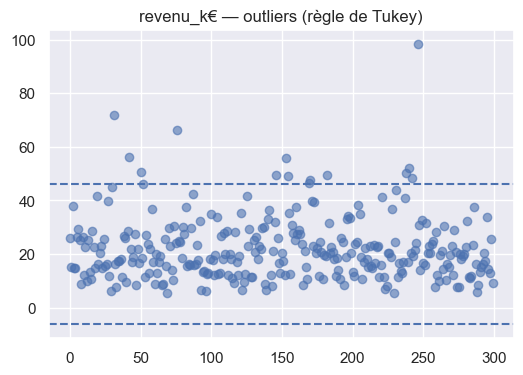

In [19]:

# Matplotlib — Mettre en évidence les outliers
col = "revenu_k€"
q1, q3 = df[col].quantile([.25,.75]); iqr = q3-q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
x = df[col]

fig, ax = plt.subplots()
ax.scatter(range(len(x)), x, alpha=0.6)
ax.axhline(lo, linestyle="--"); ax.axhline(hi, linestyle="--")
ax.set_title(f"{col} — outliers (règle de Tukey)")
plt.show()


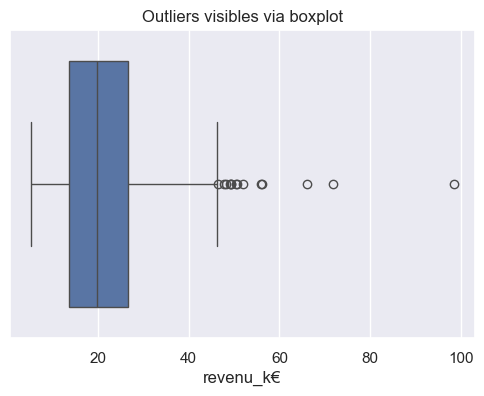

In [20]:

# Seaborn — Boxplot
sns.boxplot(x=df["revenu_k€"])
plt.title("Outliers visibles via boxplot")
plt.show()


In [21]:

# Fonction — indices des outliers + bornes
def tukey_outliers(s: pd.Series, k=1.5):
    q1, q3 = s.quantile([.25,.75]); iqr = q3-q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    mask = (s < lo) | (s > hi)
    return pd.Index(s[mask].index), (lo, hi)

idx, bounds = tukey_outliers(df["revenu_k€"])
len(idx), bounds


(14, (-6.085375542394658, 46.253813121820244))


---
## 7) Comparaisons de groupes (catégories)

On résume par **groupe** (ex : A/B/C) pour voir s'il existe des **différences** :  
- de moyenne, de dispersion, etc.  
C'est la base des analyses **segmentées** (marketing, A/B testing…).

> Rappel : des différences observées ne sont pas forcément **statistiquement significatives** (il faudrait des tests — hors périmètre de ce notebook).


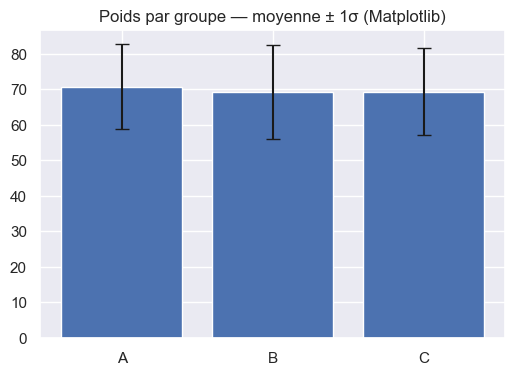

In [22]:

# Matplotlib — Barres d'erreur (moyenne ± écart-type) par groupe
g = df.groupby("groupe")["poids_kg"].agg(["mean","std"])
fig, ax = plt.subplots()
ax.bar(g.index, g["mean"], yerr=g["std"], capsize=5)
ax.set_title("Poids par groupe — moyenne ± 1σ (Matplotlib)")
plt.show()


C:\Users\didie\AppData\Local\Temp\ipykernel_10232\720832132.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x="groupe", y="poids_kg", ci=95)


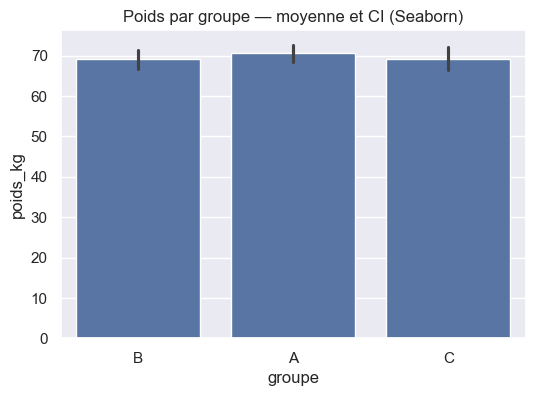

In [23]:

# Seaborn — Barplot avec intervalle de confiance (bootstrap)
sns.barplot(data=df, x="groupe", y="poids_kg", ci=95)
plt.title("Poids par groupe — moyenne et CI (Seaborn)")
plt.show()


In [24]:

# Fonction — résumé par groupe
def group_summary(df, by, col):
    return df.groupby(by)[col].agg(["count","mean","std","median","min","max"])

group_summary(df, "groupe", "poids_kg")


,count,mean,std,median,min,max
groupe,,,,,,
A,114,70.629426,11.951579,70.362251,38.294116,99.865196
B,123,69.169262,13.272450,70.376484,28.685172,101.972398
C,63,69.292276,12.305637,69.090105,42.992247,91.657680



---
## 8) Rapport express univarié (prêt à projeter)

Une fonction *tout-en-un* qui retourne les **chiffres clés** et trace deux graphes de base :
- **Histogramme** (Matplotlib) pour la forme globale,
- **Boxplot** (Seaborn) pour la dispersion et les outliers.

> Utilisation en classe : lancez d'abord ce rapport pour une **vue d'ensemble**, puis zoomez avec les fonctions unitaires des sections précédentes.


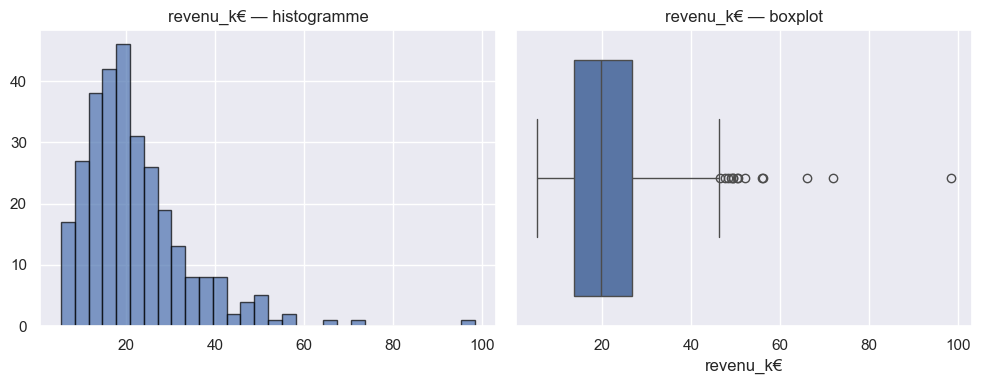

{'mean': np.float64(21.939256878822203),
 'median': np.float64(19.71477560043119),
 'mode': np.float64(5.278187611783475),
 'variance': np.float64(141.29989546893205),
 'std': np.float64(11.886963256817616),
 'Q1': np.float64(13.54182020668593),
 'Q3': np.float64(26.626617372739656),
 'IQR': np.float64(13.084797166053725),
 'skew': np.float64(1.8702991427901374),
 'kurtosis': np.float64(6.640105985180819),
 'count': 300}

In [25]:

def univariate_report(df: pd.DataFrame, col: str, bins=30, kde=True):
    s = df[col].dropna()
    # résumé
    def summarize_center(s: pd.Series):
        mode = s.mode()
        return {
            "mean": s.mean(),
            "median": s.median(),
            "mode": mode.iloc[0] if not mode.empty else None
        }
    def summarize_dispersion(s: pd.Series):
        q = s.quantile([0.25, 0.5, 0.75])
        return {
            "variance": s.var(ddof=1),
            "std": s.std(ddof=1),
            "Q1": q.loc[0.25],
            "median": q.loc[0.5],
            "Q3": q.loc[0.75],
            "IQR": q.loc[0.75] - q.loc[0.25]
        }
    def shape_metrics(s: pd.Series):
        return {"skew": s.skew(), "kurtosis": s.kurt()}

    summary = {
        **summarize_center(s),
        **summarize_dispersion(s),
        **shape_metrics(s),
        "count": s.size
    }

    # Tracés
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # Matplotlib — Histogramme
    ax[0].hist(s, bins=bins, alpha=0.7, edgecolor="black")
    ax[0].set_title(f"{col} — histogramme")
    # Seaborn — Boxplot
    sns.boxplot(x=s, ax=ax[1])
    ax[1].set_title(f"{col} — boxplot")
    plt.tight_layout()
    plt.show()

    return summary

univariate_report(df, "revenu_k€")
